In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import matplotlib

In [3]:
import seaborn as sns

In [4]:
def get_split_means(dat1_sample, value = 'Avg_Relevance'):
    return dat1_sample.groupby(['week_start', 'Third_Party_Data_Provider_Id'])[[value]].mean().pivot_table(
    index='week_start', columns='Third_Party_Data_Provider_Id', values=value)

def get_split_plots(dat1_sample, x, y, kind='scatter', logx=False, logy=False):
    ax=None
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id == 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='branded taxonomy', color='green')
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id != 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='data alliance', color='orange')
    return ax

from matplotlib.pyplot import cm
def get_split_plots2(dat1_sample, x, y, kind='scatter', by='geo', logx=False, logy=False, alpha=1):
    ax=None
    vals = set(dat1_sample[by].values)
    color = cm.rainbow(np.linspace(0, 1, len(vals)))
    for i, val in enumerate(vals):
        ax=dat1_sample[dat1_sample[by] == val].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label=val, color=color[i], alpha=alpha)
    return ax

In [5]:
data_path = "/Users/ravirajan/code/data"
output_path = "/Users/ravirajan/code/outputs"

In [7]:
#dat0 = pd.read_csv(f"{data_path}/TTD-20260608.csv", low_memory=False).replace(' ', None)
dat0 = pd.read_csv(f"{data_path}/TTD-20260615.csv", low_memory=False).replace(' ', None)
pricing = pd.read_csv(f"{data_path}/Price_Expt_Assignments2.csv")

In [8]:
dat0.head()

,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,Effective_Impression_Count,Full_Path,...,Match_Pct_Percentile,Paid_Pct,Paid_Pct_Percentile,Received_ID_Count,Selected_Pct,Selected_Pct_Percentile,Third_Party_Data_Provider_Element_Id,Third_Party_Data_Provider_Id,Third_Party_Data_Sub_Provider_Id,Week_Start_Date
0,NaN,NaN,Business and Finance,3.2,67.0,NaN,NaN,NaN,NaN,Data Alliance > Retail > Interest > Global > M...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
1,NaN,NaN,Style & Fashion,3.5,76.1,NaN,NaN,NaN,NaN,Data Alliance > Retail > Interest > Global > S...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
2,NaN,NaN,Style & Fashion,3.8,81.5,NaN,NaN,NaN,NaN,Data Alliance > Sports > Interest > Global > T...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
3,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,NaN,Data Alliance > Education > Interest > Global ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
4,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,NaN,Data Alliance > Education > Interest > Global ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00


In [9]:
base_PoM_default = {'dav2shreths':0.16, 'sharethis': 0.15}
pricing.head()    

,Unnamed: 0.1,Unnamed: 0,Third_Party_Data_Provider_Id,group,Full_Path,revenue,rev_rank,geo,assignment,incr,bucket
0,0,0.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,2421.51,1,Global,1,0.05,high
1,1,2.0,dav2shreths,0,Data Alliance > Demographic > Interest > Globa...,1983.75,2,Global,-1,0.05,high
2,2,1.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,1336.34,3,Global,0,0.05,high
3,3,4.0,dav2shreths,1,Data Alliance > Demographic > Interest > Globa...,1230.68,4,Global,0,0.05,high
4,4,3.0,dav2shreths,1,Data Alliance > Travel > Interest > Global > A...,1081.20,5,Global,1,0.05,high


In [10]:
def add_prices(dat, base_PoM_default, pricing):
    dat = dat.set_index('Third_Party_Data_Provider_Id').join(pd.DataFrame([base_PoM_default]).T[[0]]).reset_index()
    cols = list(dat.columns)
    cols[-1] = 'base_PoM'
    dat.columns = cols
    #
    pricing['delta'] = pricing['assignment'] * pricing['incr']
    dat = dat.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).join(
        pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])[['group', 'delta']], how='left').reset_index()
    dat['delta'] = dat['delta'].fillna(0)
    dat['price'] = dat['base_PoM'] + dat['delta']
    return dat

In [11]:
#dat = pd.DataFrame(dat0[dat0.Week_Start_Date > "2026-05-18"], copy=True) # prices changed 5-26 so capturing weeks from 5-18

dat = pd.DataFrame(dat0, copy=True) # prices changed 5-26 so capturing weeks from 5-18
dat['post'] = dat['Week_Start_Date'].apply(lambda x: 1 if x > "2026-05-18" else 0)

In [12]:
dat = add_prices(dat, base_PoM_default, pricing)

In [148]:
dat.head()

,Full_Path,Third_Party_Data_Provider_Id,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,...,base_PoM,group,delta,price,geo,Clean_Path,segment_last,segment_1,segment_2,week_start
0,Data Alliance > Retail > Interest > Global > M...,dav2shreths,NaN,NaN,Business and Finance,3.2,67.0,NaN,NaN,NaN,...,0.16,NaN,0.00,0.16,Global,"dataalliance>retail>interest>global>movies,mus...","movies,music,&books",dataalliance,retail,2026-01-05
1,Data Alliance > Retail > Interest > Global > S...,dav2shreths,NaN,NaN,Style & Fashion,3.5,76.1,NaN,NaN,NaN,...,0.16,NaN,0.00,0.16,Global,dataalliance>retail>interest>global>sports&out...,sportsapparel,dataalliance,retail,2026-01-05
2,Data Alliance > Sports > Interest > Global > T...,dav2shreths,NaN,NaN,Style & Fashion,3.8,81.5,NaN,NaN,NaN,...,0.16,NaN,0.00,0.16,Global,dataalliance>sports>interest>global>teamsports...,rugby,dataalliance,sports,2026-01-05
3,Data Alliance > Education > Interest > Global ...,dav2shreths,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,...,0.16,NaN,0.00,0.16,Global,dataalliance>education>interest>global>busines...,classes&programs,dataalliance,education,2026-01-05
4,Data Alliance > Education > Interest > Global ...,dav2shreths,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,...,0.16,66.0,0.05,0.21,Global,dataalliance>education>interest>global>fieldof...,psychology,dataalliance,education,2026-01-05


In [13]:
test = dat[~dat.group.isna()]
test = test[test.Week_Start_Date > "2026-05-01"]
test = test[test.Third_Party_Data_Provider_Id == 'sharethis']

In [14]:
test_means = test.groupby(['group', 'Full_Path', 'delta', 'post'])[['Data_Cost']].mean()
test_means.head()

Data_Cost
group Full_Path                                          delta post            
0.0   Global > Validated Demographic > Age > 18-44       -0.05 0     116.559048
                                                               1      90.257200
      Global > Validated Demographic > Gender > Female    0.00 0     113.526333
                                                               1     119.284667
      Global > people & society > social issues & adv...  0.05 0       1.277143

In [15]:
test_means_joined = test_means.xs(0, level='post').join(test_means.xs(1, level='post'), lsuffix='_pre', rsuffix='_post').reset_index()
test_means_joined['chg'] = test_means_joined['Data_Cost_post'] - test_means_joined['Data_Cost_pre'] 
test_means_joined['chg_ratio'] = test_means_joined['chg'] / test_means_joined['Data_Cost_pre'] 
test_means_joined.head()                                

,group,Full_Path,delta,Data_Cost_pre,Data_Cost_post,chg,chg_ratio
0,0.0,Global > Validated Demographic > Age > 18-44,-0.05,116.559048,90.257200,-26.301848,-0.225653
1,0.0,Global > Validated Demographic > Gender > Female,0.00,113.526333,119.284667,5.758333,0.050722
2,0.0,Global > people & society > social issues & ad...,0.05,1.277143,0.952857,-0.324286,-0.253915
3,1.0,Global > hobbies & leisure > outdoors,0.05,85.472000,69.055000,-16.417000,-0.192075
4,1.0,Global > law & government > legal > accident &...,0.00,205.625000,200.721667,-4.903333,-0.023846


In [16]:
test_means_joined.groupby('delta')[['chg']].describe()

chg                                                               \
       count      mean       std        min       25%       50%       75%   
delta                                                                       
-0.05  214.0  1.290278  8.361657 -26.301848 -0.122386  0.000000  0.339583   
 0.00  228.0  0.019375  2.776450 -20.048750 -0.178125 -0.004063  0.041125   
 0.05  230.0 -1.193533  8.944992 -93.923333 -0.370292 -0.007083  0.041333   

               
          max  
delta          
-0.05  85.955  
 0.00  17.335  
 0.05  39.755

In [17]:
test_means_joined[~np.isinf(test_means_joined['chg'])].groupby('delta')[['chg']].describe()

chg                                                               \
       count      mean       std        min       25%       50%       75%   
delta                                                                       
-0.05  214.0  1.290278  8.361657 -26.301848 -0.122386  0.000000  0.339583   
 0.00  228.0  0.019375  2.776450 -20.048750 -0.178125 -0.004063  0.041125   
 0.05  230.0 -1.193533  8.944992 -93.923333 -0.370292 -0.007083  0.041333   

               
          max  
delta          
-0.05  85.955  
 0.00  17.335  
 0.05  39.755

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='group', ylabel='chg'>

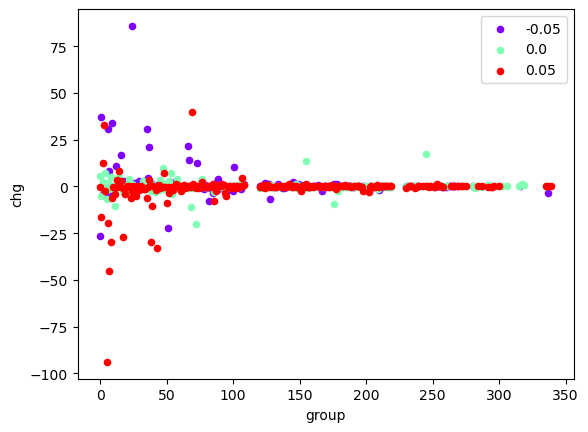

In [18]:
get_split_plots2(test_means_joined, x='group', y='chg', by='delta', logy=False, logx=False)

In [19]:
dat.head()

,Full_Path,Third_Party_Data_Provider_Id,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,...,Selected_Pct,Selected_Pct_Percentile,Third_Party_Data_Provider_Element_Id,Third_Party_Data_Sub_Provider_Id,Week_Start_Date,post,base_PoM,group,delta,price
0,Data Alliance > Retail > Interest > Global > M...,dav2shreths,NaN,NaN,Business and Finance,3.2,67.0,NaN,NaN,NaN,...,NaN,NaN,NaN,None,2026-01-05 00:00:00+00,0,0.16,NaN,0.00,0.16
1,Data Alliance > Retail > Interest > Global > S...,dav2shreths,NaN,NaN,Style & Fashion,3.5,76.1,NaN,NaN,NaN,...,NaN,NaN,NaN,None,2026-01-05 00:00:00+00,0,0.16,NaN,0.00,0.16
2,Data Alliance > Sports > Interest > Global > T...,dav2shreths,NaN,NaN,Style & Fashion,3.8,81.5,NaN,NaN,NaN,...,NaN,NaN,NaN,None,2026-01-05 00:00:00+00,0,0.16,NaN,0.00,0.16
3,Data Alliance > Education > Interest > Global ...,dav2shreths,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,...,NaN,NaN,NaN,None,2026-01-05 00:00:00+00,0,0.16,NaN,0.00,0.16
4,Data Alliance > Education > Interest > Global ...,dav2shreths,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,...,NaN,NaN,NaN,None,2026-01-05 00:00:00+00,0,0.16,66.0,0.05,0.21


In [20]:
#adv_type = "Automotive"
adv_type = "All"

In [21]:
dat.Advertiser_Category.unique()

array(['Business and Finance', 'Style & Fashion', 'Food & Drink',
       'Travel', 'News and Politics', 'Personal Finance', 'Shopping',
       'Pets', 'Home & Garden', 'Technology & Computing',
       'Events and Attractions', 'Healthy Living', 'All', 'Automotive',
       'Medical Health'], dtype=object)

In [22]:
dat.shape

(1807620, 26)

In [23]:
def get_geo(litems):
    check = ['Asia', 'US', 'Global', 'APAC']
    for c in check:
        if c in litems:
            return c
    return 'Unknown'

In [24]:
dat['geo'] = dat.Full_Path.apply(lambda x: get_geo(x.replace(" ", "").split(">")))

In [25]:
dat.groupby('geo').size()

geo
APAC         3780
Asia       384300
Global     996345
US         261765
Unknown    161430
dtype: int64

In [150]:
dat.groupby('geo')[['Data_Cost']].sum() / dat['Data_Cost'].sum()

,Data_Cost
geo,
APAC,0.014003
Asia,0.014293
Global,0.479216
US,0.326643
Unknown,0.165845


In [237]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,3780.0,0.150000,1.063179e-14,0.15,0.15,0.15,0.15,0.15
Asia,384300.0,0.150016,4.045567e-04,0.15,0.15,0.15,0.15,0.16
Global,996345.0,0.156775,3.309377e-02,0.10,0.15,0.16,0.16,0.21
US,261765.0,0.150000,7.408255e-13,0.15,0.15,0.15,0.15,0.15
Unknown,161430.0,0.150020,4.413065e-04,0.15,0.15,0.15,0.15,0.16


In [26]:
dat.head()

,Full_Path,Third_Party_Data_Provider_Id,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,...,Selected_Pct_Percentile,Third_Party_Data_Provider_Element_Id,Third_Party_Data_Sub_Provider_Id,Week_Start_Date,post,base_PoM,group,delta,price,geo
0,Data Alliance > Retail > Interest > Global > M...,dav2shreths,NaN,NaN,Business and Finance,3.2,67.0,NaN,NaN,NaN,...,NaN,NaN,None,2026-01-05 00:00:00+00,0,0.16,NaN,0.00,0.16,Global
1,Data Alliance > Retail > Interest > Global > S...,dav2shreths,NaN,NaN,Style & Fashion,3.5,76.1,NaN,NaN,NaN,...,NaN,NaN,None,2026-01-05 00:00:00+00,0,0.16,NaN,0.00,0.16,Global
2,Data Alliance > Sports > Interest > Global > T...,dav2shreths,NaN,NaN,Style & Fashion,3.8,81.5,NaN,NaN,NaN,...,NaN,NaN,None,2026-01-05 00:00:00+00,0,0.16,NaN,0.00,0.16,Global
3,Data Alliance > Education > Interest > Global ...,dav2shreths,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,...,NaN,NaN,None,2026-01-05 00:00:00+00,0,0.16,NaN,0.00,0.16,Global
4,Data Alliance > Education > Interest > Global ...,dav2shreths,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,...,NaN,NaN,None,2026-01-05 00:00:00+00,0,0.16,66.0,0.05,0.21,Global


In [27]:
dat['Clean_Path'] = dat.Full_Path.apply(lambda x: x.lower().replace(" ", ""))

array([[<Axes: title={'center': 'Received_ID_Count'}>]], dtype=object)

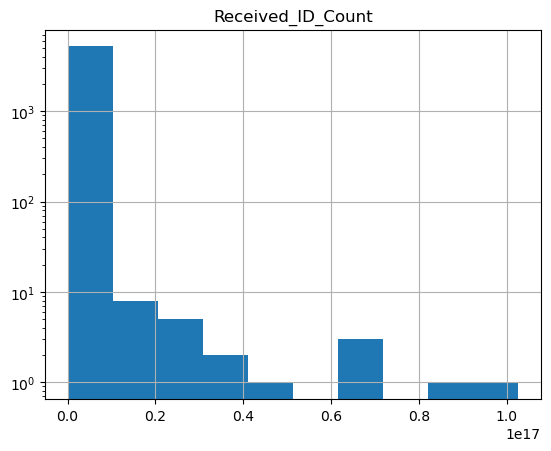

In [28]:
dat.groupby('Clean_Path')[['Received_ID_Count']].var().hist(log=True)

In [29]:
dat['segment_last'] = dat.Clean_Path.apply(lambda x: x.split(">")[-1].replace("age", ""))
dat['segment_1'] = dat.Clean_Path.apply(lambda x: x.split(">")[0])
##dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.replace("otp>", "").split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['week_start'] = dat.Week_Start_Date.apply(lambda x: x.split(" ")[0])

In [30]:
dat.groupby('Third_Party_Data_Provider_Id')['segment_last'].unique()

Third_Party_Data_Provider_Id
dav2shreths    [movies,music,&books, sportsapparel, rugby, cl...
sharethis      [homeentertaining, electronics, financeandacco...
Name: segment_last, dtype: object

In [31]:
#seg_last_vb = list(dat[dat.Third_Party_Data_Provider_Id == 'sharethis']['segment_last'].unique())
#seg_last_da = list(dat[dat.Third_Party_Data_Provider_Id == 'dav2shreths']['segment_last'].unique())

In [32]:
seg_last_vb = pd.DataFrame(dat[dat.Third_Party_Data_Provider_Id == 'sharethis']['segment_last'].value_counts())
seg_last_da = pd.DataFrame(dat[dat.Third_Party_Data_Provider_Id == 'dav2shreths']['segment_last'].value_counts())

In [33]:
seg_last_vb.describe()

,count
count,1728.000000
mean,654.878472
std,319.874509
min,75.000000
25%,315.000000
50%,630.000000
75%,945.000000
max,2835.000000


In [34]:
seg_last_da.describe()

,count
count,1764.000000
mean,383.214286
std,306.145298
min,315.000000
25%,315.000000
50%,315.000000
75%,315.000000
max,10710.000000


In [35]:
len(set(dat['segment_last']))

3208

In [36]:
def find_common_substrings(list1, list2, fuzzy_only=True):
    """
    Finds all strings from list1 that are substrings of any string in list2.
    """
    common_subs = set()
    matches = []
    exact_matches = set()
    for s1 in list1:
        for s2 in list2:
            if s1 == s2:
                exact_matches.add(s1)
                if fuzzy_only:
                    continue
            if len(s1) > 2 and s1.lower() in s2.lower():
                common_subs.add(s1.lower())
                matches.append([s1, s2])
            elif len(s2) > 2 and s2.lower() in s1.lower():
                common_subs.add(s2.lower())
                matches.append([s1, s2])
    return list(common_subs), matches, exact_matches

In [37]:
seg_common, matches, exact_matches = find_common_substrings(seg_last_vb[seg_last_vb["count"] > 1].index, 
                                             seg_last_da[seg_last_da["count"] > 1].index)
len(seg_common)

507

In [38]:
#matches

In [39]:
#exact_matches

In [40]:
#for k in exact_matches:
#    print (k, seg_last_vb.loc[k].values[0], seg_last_da.loc[k].values[0])

In [41]:
dat.tail()

,Full_Path,Third_Party_Data_Provider_Id,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,...,base_PoM,group,delta,price,geo,Clean_Path,segment_last,segment_1,segment_2,week_start
1807615,US > food & drink > beverages > coffee & tea,sharethis,NaN,NaN,Style & Fashion,4.2,80.0,NaN,NaN,NaN,...,0.15,NaN,0.0,0.15,US,us>food&drink>beverages>coffee&tea,coffee&tea,us,food&drink,2026-05-25
1807616,US > food & drink > beverages > juice,sharethis,64342000.0,98.8,Events and Attractions,5.4,88.7,98.6,76.0,0.00,...,0.15,NaN,0.0,0.15,US,us>food&drink>beverages>juice,juice,us,food&drink,2026-05-25
1807617,US > food & drink > beverages > soft drinks,sharethis,NaN,NaN,Automotive,5.8,87.0,NaN,NaN,NaN,...,0.15,NaN,0.0,0.15,US,us>food&drink>beverages>softdrinks,softdrinks,us,food&drink,2026-05-25
1807618,US > food & drink > beverages > soft drinks,sharethis,173782900.0,98.6,Food & Drink,4.8,87.0,98.9,68.0,0.08,...,0.15,NaN,0.0,0.15,US,us>food&drink>beverages>softdrinks,softdrinks,us,food&drink,2026-05-25
1807619,US > food & drink > beverages > soft drinks,sharethis,NaN,NaN,Pets,4.7,84.1,NaN,NaN,NaN,...,0.15,NaN,0.0,0.15,US,us>food&drink>beverages>softdrinks,softdrinks,us,food&drink,2026-05-25


In [42]:
len(dat['segment_last'].unique()), len(dat['segment_1'].unique()), len(dat['segment_2'].unique())

(3208, 19, 82)

In [43]:
dat.groupby(['Third_Party_Data_Provider_Id','segment_last']).size()

Third_Party_Data_Provider_Id  segment_last                
dav2shreths                   1-3months                       315
                              1-star                          315
                              10+vehicles                     315
                              1500                            315
                              18-20                           315
                                                             ... 
sharethis                     yoga&pilates                    945
                              yogurt                          315
                              youthorganizations&resources    315
                              zeroproof                       315
                              zoos-aquariums-preserves        945
Length: 3492, dtype: int64

In [44]:
dat.groupby(['Third_Party_Data_Provider_Id','segment_last']).size().groupby('Third_Party_Data_Provider_Id').size()

Third_Party_Data_Provider_Id
dav2shreths    1764
sharethis      1728
dtype: int64

In [45]:
dat.groupby(['geo','segment_last']).size().groupby('geo').size()

geo
APAC         12
Asia       1145
Global     2565
US          822
Unknown     447
dtype: int64

In [46]:
dat['segment_1'].unique()

array(['dataalliance', 'asia', 'b2b', 'us', 'global', 'intent',
       'political', 'winterholiday', 'interestfromsocialactivity', 'otp',
       'highintentdemocraticpbt', 'highintentrepublicanpbt',
       'middleeastconflict', 'midterms', 'keymidtermcandidates',
       'keymidtermhouseraces', 'keymidtermsenateraces', 'affordability',
       'governorsandstatewidemidtermelections'], dtype=object)

In [47]:
#seg1 = 'otp'
#dat[dat.segment_1 == seg1]['Full_Path'].values[-10:]

#otp -> 3rd & last
#b2b -> 2nd & last
#datalliance -> 2nd & last
# interestfromsocialactivity -> last
# global -> 2nd & last
# us -> last (or 3rd?)
# politcal -> last
# intent -> 2nd & last?
# winterholiday -> last or 2nd
# asian -> 2nd & last?

In [48]:
dat['segment_2'].unique()

array(['retail', 'sports', 'education', 'cpg', 'automotive',
       'technology&computing', 'arts&entertainment', 'news&politics',
       'lifestyle&living', 'games&gaming', 'business&finance',
       'pets&animals', 'food&beverages', 'books&literature',
       'demographic', 'hobbies&interests', 'travel', 'health&wellness',
       'style&fashion', 'shopping', 'realestate', 'home&garden',
       'career&jobs', 'thechangingconsumer', 'industry',
       'professionalgroups', 'validateddemographic',
       'computers&electronics', 'business&industrial', 'dataforgood',
       'finance', 'law&government', 'intent', 'autos&vehicles',
       'jobs&education', 'beauty&fitness', 'food&drink', 'games',
       'lifeevent', 'science', 'hobbies&leisure', 'onlinecommunities',
       'people&society', 'politician', 'supremecourt', 'reference',
       'autobuyers', 'toyshoppers', 'services', 'seasonal',
       'financialintent', 'functionalarea', 'health', 'urlaudience',
       'internet&telecom', 'me

In [49]:
dat.groupby('geo').size()

geo
APAC         3780
Asia       384300
Global     996345
US         261765
Unknown    161430
dtype: int64

# EDA

In [50]:
dat1 = dat[dat.Received_ID_Count.isna() == False]
dat1 = dat1[dat1.Advertiser_Category == adv_type]  
dat1.shape

(81421, 32)

In [51]:
dat1['Received_ID_Count'] = dat1['Received_ID_Count'].astype(int)
dat1['Active_ID_Count'] = dat1['Active_ID_Count'].astype(int)
dat1['Effective_Impression_Count'] = dat1['Effective_Impression_Count'].astype(int)

In [52]:
dat['Data_Cost'] = dat['Data_Cost'].astype(float)
dat1['Match_Pct'] = dat1['Match_Pct'].astype(float)
dat1['Match_Pct_Percentile'] = dat1['Match_Pct_Percentile'].astype(float)

In [53]:
dat1_sample = dat1.sample(1000)
dat1_sample.head()

,Full_Path,Third_Party_Data_Provider_Id,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,...,base_PoM,group,delta,price,geo,Clean_Path,segment_last,segment_1,segment_2,week_start
1186682,US > autos & vehicles > vehicle brands > GMC >...,sharethis,120365400,95.8,All,14.1,88.0,95.7,67.0,19.75,...,0.15,NaN,0.0,0.15,US,us>autos&vehicles>vehiclebrands>gmc>gmcterrain,gmcterrain,us,autos&vehicles,2026-02-16
190612,B2B > Occupation > Architect,sharethis,8382600,88.2,All,5.1,89.5,96.5,62.0,43.74,...,0.15,NaN,0.0,0.15,Unknown,b2b>occupation>architect,architect,b2b,occupation,2026-01-05
152859,Asia > Home & Garden > Gardening & Landscaping,sharethis,3276600,83.7,All,3.6,38.8,75.5,39.0,0.03,...,0.15,NaN,0.0,0.15,Asia,asia>home&garden>gardening&landscaping,gardening&landscaping,asia,home&garden,2026-03-02
1134705,US > games > computer & video games > casual g...,sharethis,134129800,96.2,All,8.5,89.4,96.2,70.0,0.05,...,0.15,NaN,0.0,0.15,US,us>games>computer&videogames>casualgames,casualgames,us,games,2026-01-26
829961,Asia > Internet & Telecom > Web Services > Web...,sharethis,6338700,85.1,All,1.5,33.4,73.0,31.0,0.03,...,0.15,NaN,0.0,0.15,Asia,asia>internet&telecom>webservices>webdesign&de...,webdesign&development,asia,internet&telecom,2026-04-27


In [54]:
dat1_sample['revenue_per_user'] = dat1_sample['Data_Cost'] / dat1_sample['Received_ID_Count']
dat1_sample['revenue_per_active_user'] = dat1_sample['Data_Cost'] / dat1_sample['Active_ID_Count']

In [55]:
dat1_sample['ecpm'] = dat1_sample['Data_Cost'] / dat1_sample['Effective_Impression_Count']

<Axes: title={'center': 'number of segments'}, xlabel='week_start'>

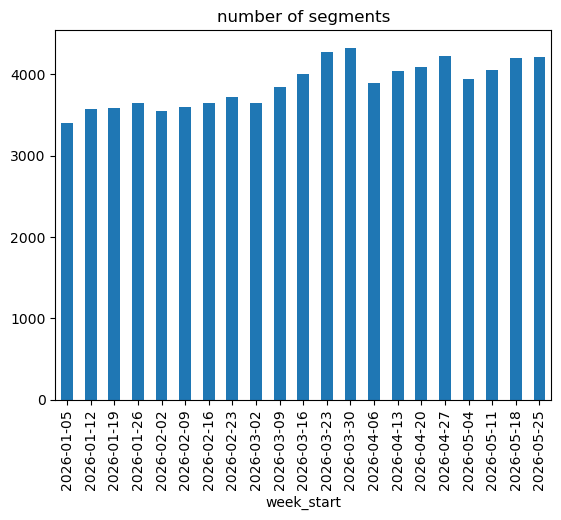

In [56]:
dat1.groupby('week_start').size().plot(kind='bar', title='number of segments')

In [57]:
get_split_means(dat1_sample, value = 'Avg_Relevance')

Third_Party_Data_Provider_Id,dav2shreths,sharethis
week_start,,
2026-01-05,5.142857,3.554286
2026-01-12,4.688235,3.596429
2026-01-19,4.336364,3.385000
2026-01-26,8.946154,6.303226
2026-02-02,6.942857,5.140000
2026-02-09,4.800000,3.606452
2026-02-16,13.964286,10.742424
2026-02-23,16.700000,12.991429
2026-03-02,12.172222,8.180000


In [58]:
get_split_means(dat1_sample, value = 'Data_Cost')

Third_Party_Data_Provider_Id,dav2shreths,sharethis
week_start,,
2026-01-05,0.440000,11.887143
2026-01-12,15.195294,2.936071
2026-01-19,2.762727,3.640750
2026-01-26,0.948462,5.830645
2026-02-02,0.580000,6.892000
2026-02-09,0.251818,13.421290
2026-02-16,1.315000,4.791818
2026-02-23,11.464667,48.427429
2026-03-02,2.156111,2.896000


<Axes: title={'center': 'avg(relevance) over time'}, xlabel='week_start', ylabel='relevance'>

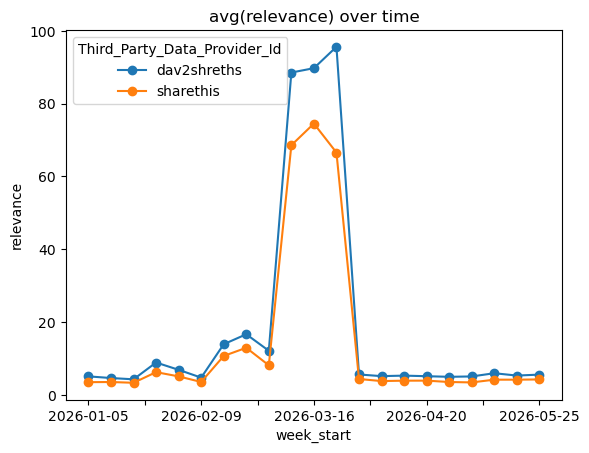

In [59]:
get_split_means(dat1_sample, value = 'Avg_Relevance').plot(marker='o', title='avg(relevance) over time', ylabel='relevance')

<Axes: title={'center': 'avg(revenue) over time'}, xlabel='week_start', ylabel='revenue'>

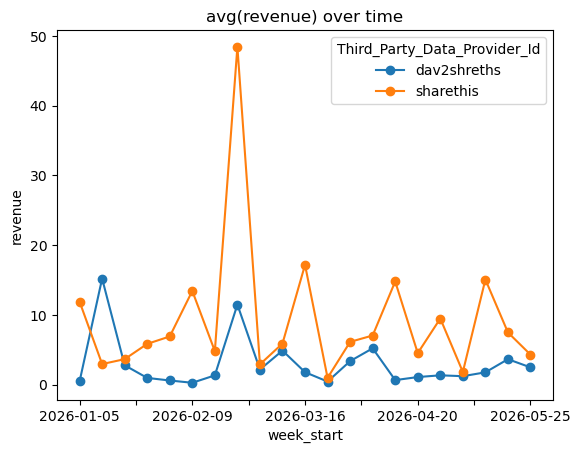

In [60]:
get_split_means(dat1_sample, value = 'Data_Cost').plot(marker='o', title='avg(revenue) over time', ylabel='revenue')

In [61]:
dat1[['Data_Cost', 'Avg_Relevance', 'Avg_Relevance_Percentile']].corr()

,Data_Cost,Avg_Relevance,Avg_Relevance_Percentile
Data_Cost,1.000000,0.004543,0.026943
Avg_Relevance,0.004543,1.000000,0.250802
Avg_Relevance_Percentile,0.026943,0.250802,1.000000


<Axes: xlabel='week_start'>

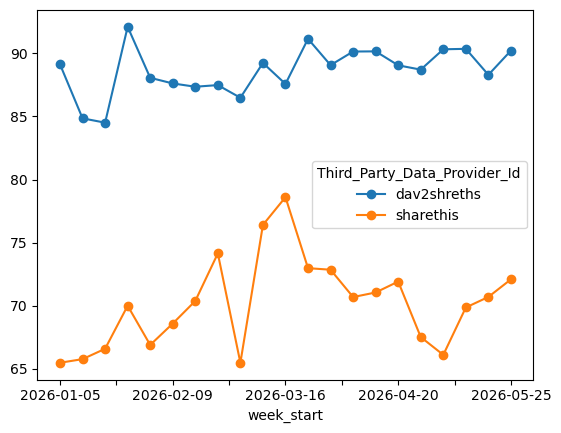

In [62]:
get_split_means(dat1_sample, value = 'Avg_Relevance_Percentile').plot(marker='o')

<Axes: xlabel='Received_ID_Count', ylabel='Active_ID_Count'>

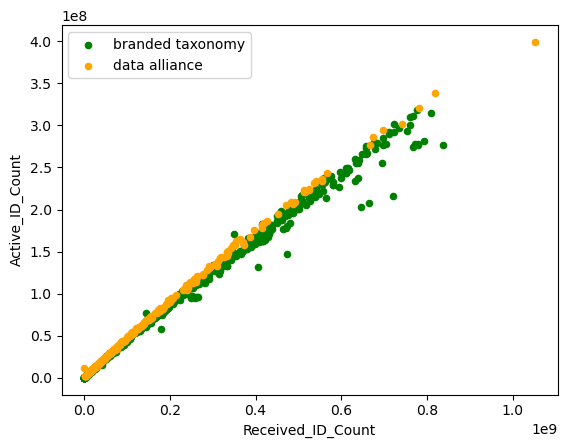

In [63]:
get_split_plots(dat1_sample, x='Received_ID_Count', y='Active_ID_Count')
#get_split_plots2(dat1_sample, x='Received_ID_Count', y='Active_ID_Count', by='geo')

In [151]:
#(dat1_sample['Active_ID_Count'] / dat1_sample['Received_ID_Count']).hist()

In [152]:
#(dat1_sample['Active_ID_Count'] / dat1_sample['Received_ID_Count']).mean()

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='Effective_Impression_Count'>

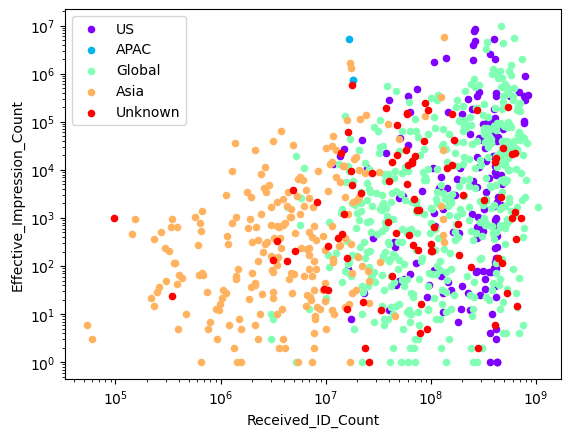

In [66]:
#get_split_plots(dat1_sample, x='Received_ID_Count', y='Effective_Impression_Count', logy=True, logx=True)
get_split_plots2(dat1_sample, x='Received_ID_Count', y='Effective_Impression_Count', by='geo', logy=True, logx=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='Effective_Impression_Count'>

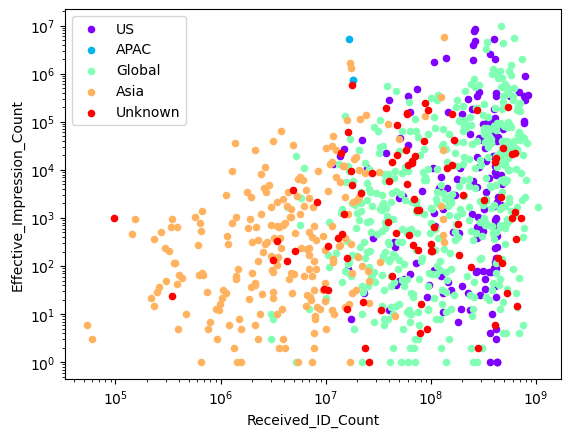

In [67]:
#get_split_plots(dat1_sample, x='Received_ID_Count', y='Effective_Impression_Count', logy=True, logx=True)
get_split_plots2(dat1_sample, x='Received_ID_Count', y='Effective_Impression_Count', by='geo', logy=True, logx=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Active_ID_Count', ylabel='Effective_Impression_Count'>

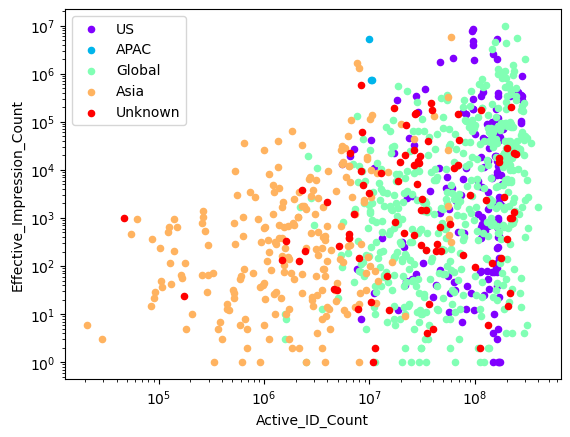

In [68]:
#get_split_plots(dat1_sample, x='Active_ID_Count', y='Effective_Impression_Count', logy=True, logx=True)
get_split_plots2(dat1_sample, x='Active_ID_Count', y='Effective_Impression_Count', by='geo', logy=True, logx=True)

<Axes: xlabel='Avg_Relevance', ylabel='Effective_Impression_Count'>

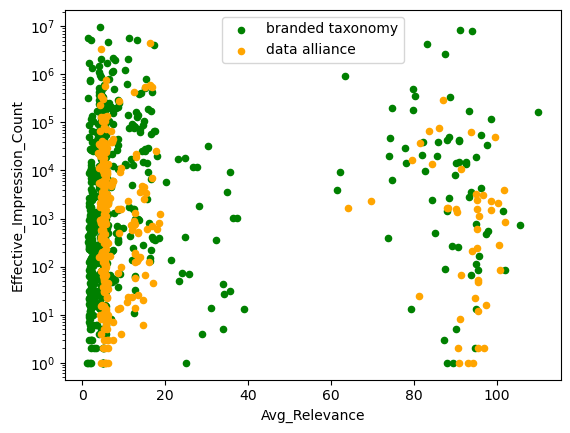

In [69]:
get_split_plots(dat1_sample, x='Avg_Relevance', y='Effective_Impression_Count', logy=True, logx=False)

<Axes: xlabel='Effective_Impression_Count', ylabel='Data_Cost'>

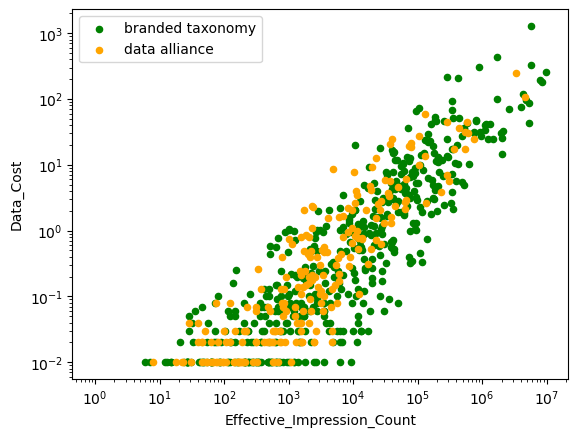

In [70]:
get_split_plots(dat1_sample, y='Data_Cost', x='Effective_Impression_Count', logy=True, logx=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='Avg_Relevance'>

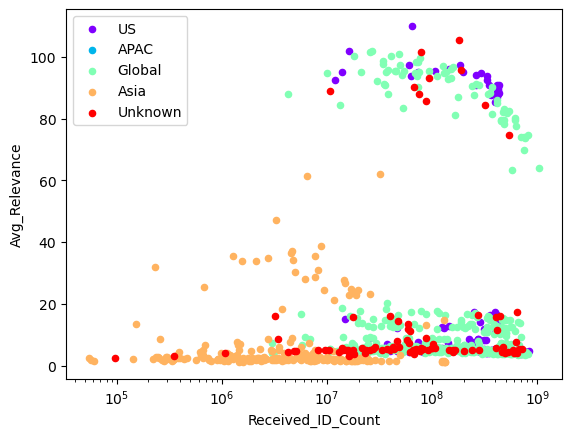

In [71]:
get_split_plots2(dat1_sample, y='Avg_Relevance', x='Received_ID_Count', by='geo', logy=False, logx=True)

<Axes: xlabel='Received_ID_Count', ylabel='Match_Pct'>

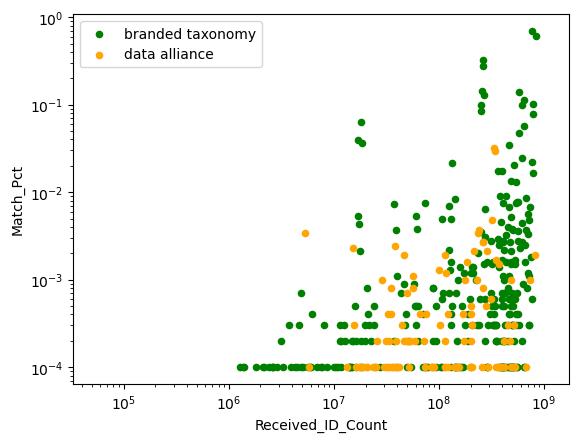

In [72]:
get_split_plots(dat1_sample, y='Match_Pct', x='Received_ID_Count', logy=True, logx=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='Data_Cost'>

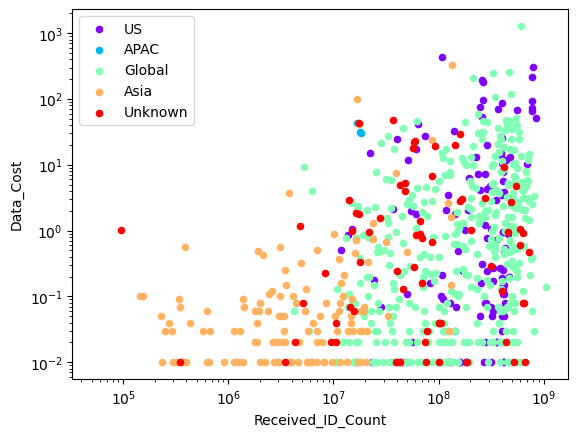

In [73]:
get_split_plots2(dat1_sample, x='Received_ID_Count', y='Data_Cost', kind='scatter', by='geo', logx=True, logy=True)

<Axes: xlabel='Avg_Relevance', ylabel='revenue_per_user'>

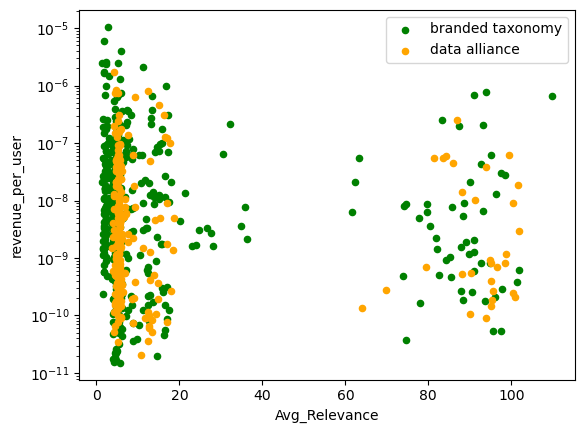

In [74]:
get_split_plots(dat1_sample, y='revenue_per_user', x='Avg_Relevance', logy=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Avg_Relevance', ylabel='revenue_per_user'>

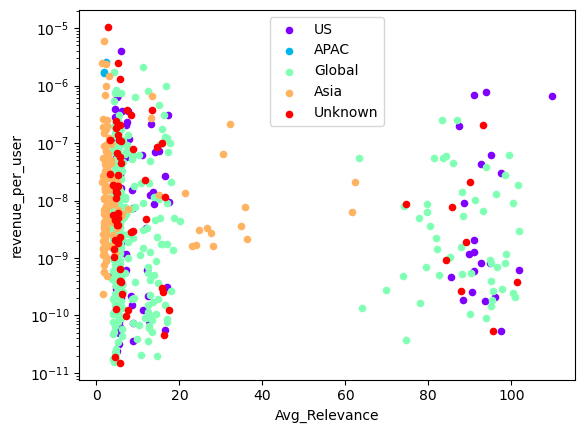

In [75]:
get_split_plots2(dat1_sample, x='Avg_Relevance', y='revenue_per_user', kind='scatter', by='geo', logx=False, logy=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='revenue_per_user'>

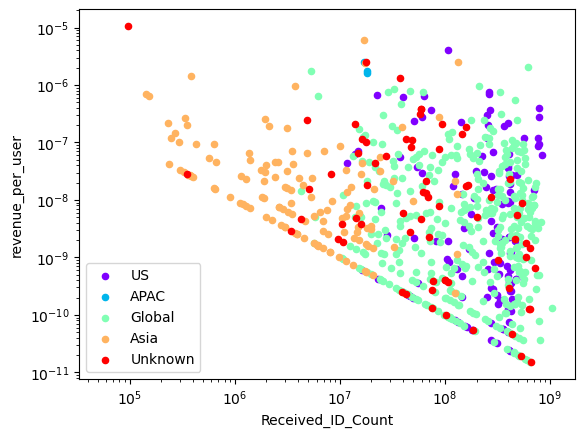

In [76]:
get_split_plots2(dat1_sample, x='Received_ID_Count', y='revenue_per_user', kind='scatter', by='geo', logx=True, logy=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Avg_Relevance', ylabel='ecpm'>

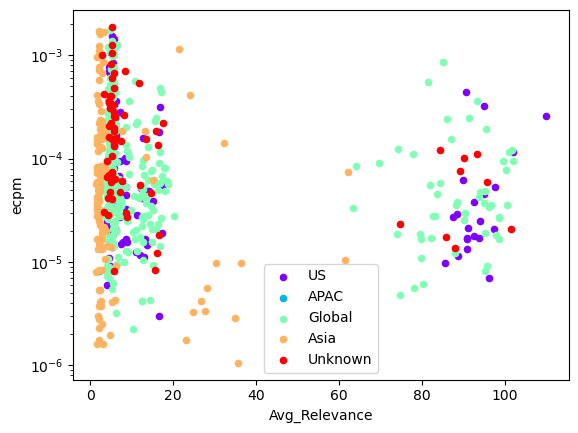

In [77]:
get_split_plots2(dat1_sample, x='Avg_Relevance', y='ecpm', kind='scatter', by='geo', logx=False, logy=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='ecpm', ylabel='Data_Cost'>

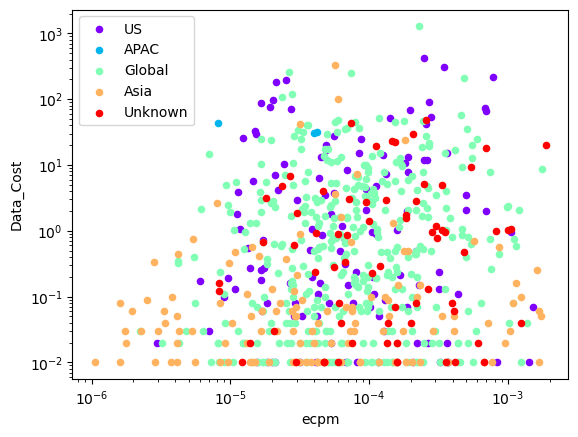

In [78]:
get_split_plots2(dat1_sample, y='Data_Cost', x='ecpm', kind='scatter', by='geo', logx=True, logy=True)

<Axes: xlabel='Avg_Relevance', ylabel='Match_Pct'>

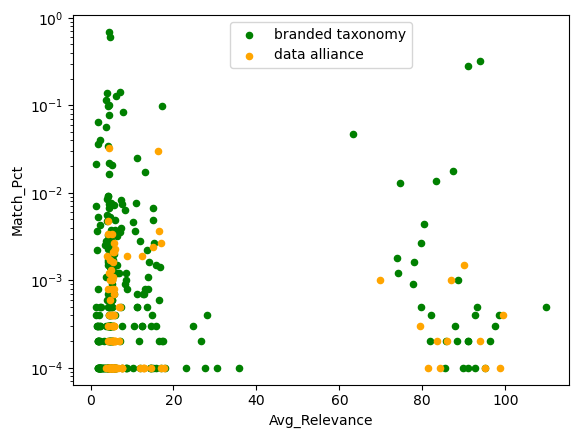

In [79]:
get_split_plots(dat1_sample, y='Match_Pct', x='Avg_Relevance', logy=True, logx=False)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Avg_Relevance', ylabel='Data_Cost'>

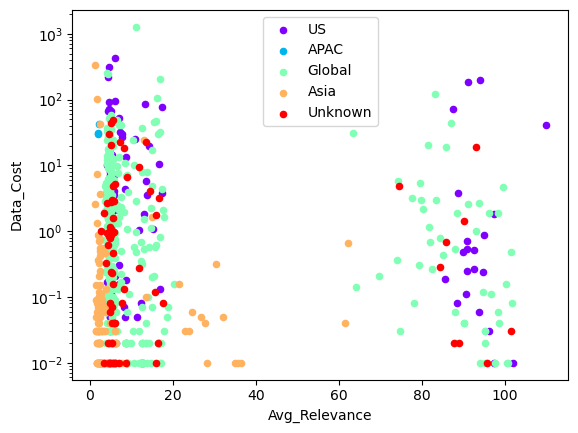

In [80]:
#get_split_plots(dat1_sample, y='Data_Cost', x='Avg_Relevance', logy=True, logx=False)
get_split_plots2(dat1_sample, y='Data_Cost', x='Avg_Relevance', by='geo', logy=True, logx=False)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Avg_Relevance_Percentile', ylabel='Data_Cost'>

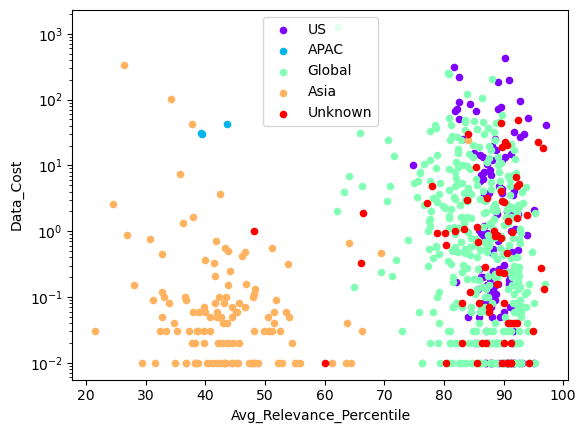

In [81]:
#get_split_plots(dat1_sample, y='Data_Cost', x='Avg_Relevance_Percentile', logy=True, logx=False)
get_split_plots2(dat1_sample, y='Data_Cost', by='geo', x='Avg_Relevance_Percentile', logy=True, logx=False)

In [82]:
dat1[['Received_ID_Count', 'Active_ID_Count', 'Effective_Impression_Count', 'Avg_Relevance', 'Match_Pct', 'Avg_Relevance_Percentile']].astype(float).describe(
    percentiles = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
).round(2)

,Received_ID_Count,Active_ID_Count,Effective_Impression_Count,Avg_Relevance,Match_Pct,Avg_Relevance_Percentile
count,8.142100e+04,8.142100e+04,81421.00,81421.00,81421.00,81421.00
mean,1.845468e+08,7.737176e+07,132270.48,16.16,0.00,75.81
std,2.073875e+08,8.308777e+07,877294.56,27.26,0.03,20.10
min,0.000000e+00,7.000000e+02,0.00,1.00,0.00,13.70
5%,7.600000e+05,3.574000e+05,0.00,1.80,0.00,36.60
10%,2.412180e+06,1.127700e+06,4.00,2.10,0.00,40.50
25%,1.524020e+07,7.378500e+06,53.00,4.30,0.00,64.30
50%,8.958340e+07,4.142140e+07,953.00,5.20,0.00,85.70
75%,3.316578e+08,1.406922e+08,18316.00,9.30,0.00,89.80
90%,5.033057e+08,2.083506e+08,145452.00,80.40,0.00,92.10


array([[<Axes: title={'center': 'Received_ID_Count'}>,
        <Axes: title={'center': 'Effective_Impression_Count'}>]],
      dtype=object)

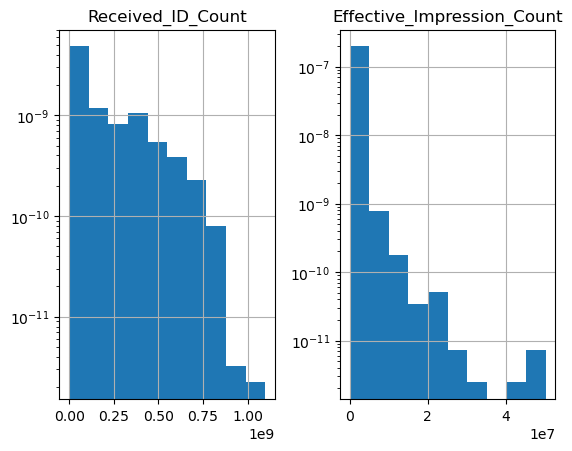

In [83]:
dat1[['Received_ID_Count', 'Effective_Impression_Count']].astype(float).hist(density=True, log=True)

In [84]:
#dat1.hist(column=['Received_ID_Count', 'Effective_Impression_Count'], density=True, by='Third_Party_Data_Provider_Id', log=True)

In [85]:
dat1[['Received_ID_Count', 'Effective_Impression_Count']].astype(float).describe(
    percentiles = [0.1, 0.5, 0.9]
).round(2)

,Received_ID_Count,Effective_Impression_Count
count,8.142100e+04,81421.00
mean,1.845468e+08,132270.48
std,2.073875e+08,877294.56
min,0.000000e+00,0.00
10%,2.412180e+06,4.00
50%,8.958340e+07,953.00
90%,5.033057e+08,145452.00
max,1.098071e+09,50083815.00


In [86]:
dat1['Match_Pct'].max(), dat1['Effective_Impression_Count'].quantile(0.95).round(2), dat1['Received_ID_Count'].quantile(0.05).round(2)

(1.0485, 430058.0, 760000.0)

array([[<Axes: title={'center': 'Received_ID_Count'}>,
        <Axes: title={'center': 'Active_ID_Count'}>,
        <Axes: title={'center': 'Effective_Impression_Count'}>]],
      dtype=object)

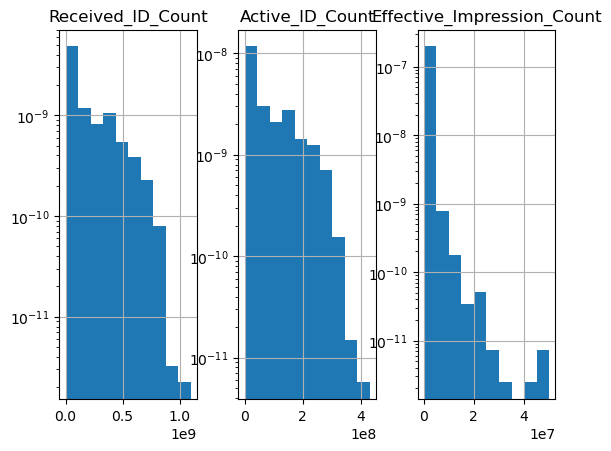

In [87]:
dat1[['Received_ID_Count', 'Active_ID_Count', 'Effective_Impression_Count']].astype(float).hist(density=True, layout=(1,3), log=True)

array([[<Axes: title={'center': 'Match_Pct'}>,
        <Axes: title={'center': 'Avg_Relevance'}>,
        <Axes: title={'center': 'Avg_Relevance_Percentile'}>]],
      dtype=object)

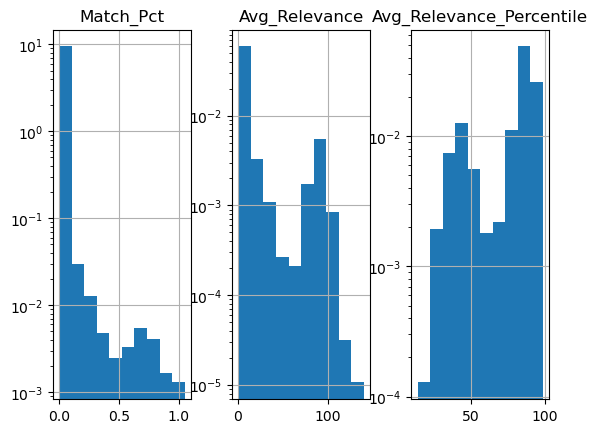

In [88]:
dat1[['Match_Pct', 'Avg_Relevance', 'Avg_Relevance_Percentile']].astype(float).hist(density=True, layout=(1,3), log=True)

## filter out bad rows

In [184]:
#dat1.head()

In [185]:
dat2 = dat1[dat1.Received_ID_Count > 0]
dat2 = dat2[~dat2.group.isna()]

array([[<Axes: title={'center': 'Avg_Relevance_Percentile'}>,
        <Axes: title={'center': 'Data_Cost'}>]], dtype=object)

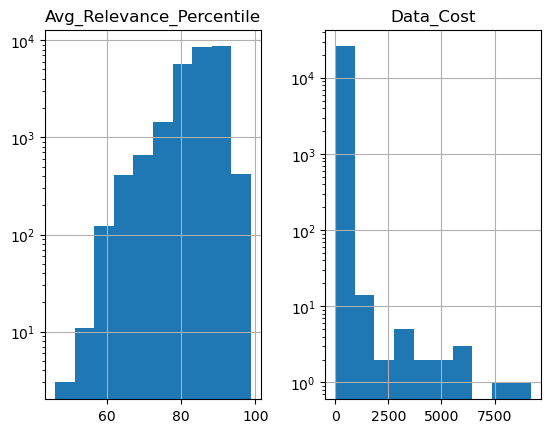

In [186]:
dat2[['Avg_Relevance_Percentile', 'Data_Cost']].hist(log=True)

# Model

In [153]:
#dat3 = dat2
#dat3 = dat2[~dat2.group.isna()]

In [187]:
yr = dat2['Avg_Relevance_Percentile'] #['Avg_Relevance']
yd = dat2['Data_Cost'].astype(float) 

In [188]:
#seg_col = 'segment_last'
seg_col = 'segment_2'
#seg_col = 'Full_Path'

In [189]:
x_c_cols = list(dict.fromkeys([seg_col, 'week_start', 'Advertiser_Category', 'Third_Party_Data_Provider_Id', 'geo', 'segment_2']))
x_n_cols = ['Received_ID_Count', 'price', 'Avg_Relevance_Percentile'] #[ 'Active_ID_Count_Percentile', 'Paid_Pct_Percentile']
# 'Avg_Value_Percentile' has NAs

In [190]:
Xn = pd.DataFrame(dat2[x_n_cols], dtype=float)
Xn['log_Received_ID_Count'] = Xn['Received_ID_Count'].apply(lambda x: np.log(x))
x_n_cols += ['log_Received_ID_Count']

In [191]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
Xn = pd.DataFrame(sc.fit_transform(Xn), columns=Xn.columns, index=Xn.index)

In [192]:
Xc = pd.get_dummies(dat2[x_c_cols])

In [193]:
#matches

In [194]:
#Xc.head()

In [195]:
#Xn.head()

In [196]:
X = Xn.join(Xc)
X.head()

,Received_ID_Count,price,Avg_Relevance_Percentile,log_Received_ID_Count,segment_2_arts&entertainment,segment_2_automotive,segment_2_autos&vehicles,segment_2_beauty&fitness,segment_2_books&literature,segment_2_business&finance,...,week_start_2026-04-20,week_start_2026-04-27,week_start_2026-05-04,week_start_2026-05-11,week_start_2026-05-18,week_start_2026-05-25,Advertiser_Category_All,Third_Party_Data_Provider_Id_dav2shreths,Third_Party_Data_Provider_Id_sharethis,geo_Global
246,-1.084075,0.126524,0.749684,-1.068907,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
378,-1.238617,-1.089444,0.573604,-1.965256,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True
379,-0.904363,1.342491,0.525583,-0.585065,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True
397,-1.137060,1.342491,0.829720,-1.285068,False,True,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
436,1.451356,1.342491,-1.699421,1.047845,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True


In [197]:
X.shape

(25914, 73)

### Revenue

In [198]:
from sklearn.linear_model import Ridge

mod_d = Ridge(alpha=0.000001)
mod_d.fit(X, yd)
mod_d.score(X, yd)

0.026768597476427458

In [199]:
coef_d = pd.DataFrame(mod_d.coef_, index=X.columns, columns=['beta'])
coef_d['abs_beta'] = coef_d['beta'].abs()
coef_d_sorted = coef_d.sort_values('abs_beta', ascending=False)

In [200]:
coef_d_sorted[coef_d_sorted.beta > 0].filter(regex=seg_col, axis='index').head(15)

,beta,abs_beta
segment_2_people&society,81.184953,81.184953
segment_2_travel,47.823349,47.823349
segment_2_demographic,40.490086,40.490086
segment_2_validateddemographic,37.339149,37.339149
segment_2_realestate,17.315325,17.315325
segment_2_law&government,16.248050,16.248050
segment_2_business&finance,15.221583,15.221583
segment_2_hobbies&leisure,6.780166,6.780166
segment_2_health&wellness,6.179079,6.179079
segment_2_career&jobs,4.811777,4.811777


In [201]:
coef_d_sorted[coef_d_sorted.beta < 0].filter(regex=seg_col, axis='index').head(15)

,beta,abs_beta
segment_2_science,-20.564727,20.564727
segment_2_dataforgood,-19.565582,19.565582
segment_2_jobs&education,-19.129523,19.129523
segment_2_games,-19.060321,19.060321
segment_2_reference,-16.968085,16.968085
segment_2_thechangingconsumer,-13.860692,13.860692
segment_2_global,-13.523232,13.523232
segment_2_beauty&fitness,-13.300193,13.300193
segment_2_food&drink,-12.518998,12.518998
segment_2_shopping,-12.025475,12.025475


In [202]:
coef_d.filter(regex='Received', axis='index')

,beta,abs_beta
Received_ID_Count,9.049719,9.049719
log_Received_ID_Count,2.773285,2.773285


In [203]:
coef_d.filter(regex='geo_', axis='index')

,beta,abs_beta
geo_Global,0.0,0.0


In [204]:
coef_d.filter(regex='Third_Party_Data_Provider_Id', axis='index')

,beta,abs_beta
Third_Party_Data_Provider_Id_dav2shreths,-4.130484,4.130484
Third_Party_Data_Provider_Id_sharethis,4.130478,4.130478


In [205]:
coef_d.filter(regex='price', axis='index')

,beta,abs_beta
price,3.603158,3.603158


In [206]:
segs_check = [x.replace(seg_col+'_', '') for x in coef_d_sorted.index[:1]]
dat2[dat2[seg_col].isin(segs_check)].head(5).T

,7388,11658,12433,13941,14255
Full_Path,Global > people & society > social issues & ad...,Global > people & society > social issues & ad...,Global > people & society > social issues & ad...,Global > people & society > family & relations...,Global > people & society > seniors & retirement
Third_Party_Data_Provider_Id,sharethis,sharethis,sharethis,sharethis,sharethis
Active_ID_Count,63251300,274622100,154806100,89369400,185791500
Active_ID_Count_Percentile,94.3,98.1,96.7,95.2,97.1
Advertiser_Category,All,All,All,All,All
Avg_Relevance,4.6,4.0,4.5,4.5,4.3
Avg_Relevance_Percentile,86.1,74.5,83.2,83.5,80.4
Avg_Value_Percentile,93.2,92.4,94.8,93.2,94.0
Avg_Value_Score,57.0,56.0,59.0,57.0,58.0
Data_Cost,0.35,0.0,14.65,0.55,2.42


In [207]:
segs_d_check = [x.replace(seg_col+'_', '') for x in coef_d_sorted.index[:1]]
dat2[dat2[seg_col].isin(segs_d_check)].head(5).T

,7388,11658,12433,13941,14255
Full_Path,Global > people & society > social issues & ad...,Global > people & society > social issues & ad...,Global > people & society > social issues & ad...,Global > people & society > family & relations...,Global > people & society > seniors & retirement
Third_Party_Data_Provider_Id,sharethis,sharethis,sharethis,sharethis,sharethis
Active_ID_Count,63251300,274622100,154806100,89369400,185791500
Active_ID_Count_Percentile,94.3,98.1,96.7,95.2,97.1
Advertiser_Category,All,All,All,All,All
Avg_Relevance,4.6,4.0,4.5,4.5,4.3
Avg_Relevance_Percentile,86.1,74.5,83.2,83.5,80.4
Avg_Value_Percentile,93.2,92.4,94.8,93.2,94.0
Avg_Value_Score,57.0,56.0,59.0,57.0,58.0
Data_Cost,0.35,0.0,14.65,0.55,2.42


<Axes: xlabel='Avg_Relevance', ylabel='Data_Cost'>

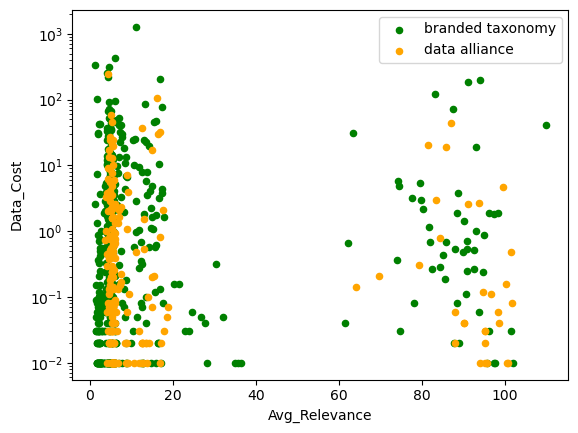

In [208]:
# for comparison
get_split_plots(dat1_sample, y='Data_Cost', x='Avg_Relevance', logy=True, logx=False)

In [209]:
import matplotlib.pyplot as plt

def dfScatter(df, xcol='beta', ycol='Received_ID_Count', catcol='criterion', logx=False, logy=False):
    #fig, ax = plt.subplots()
    categories = np.unique(df[catcol])
    colors = np.linspace(0, 1, len(categories))
    colordict = dict(zip(categories, colors))  

    colors = df[catcol].apply(lambda x: colordict[x])
    #x.scatter(df[xcol], df[ycol], c=colors, logx=logx, logy=logy)
    return df.plot(kind='scatter', x=xcol, y=ycol, logy=logy, logx=logx, c=colors)
    #return df.plot(kind='scatter', x='beta', y='Received_ID_Count', logy=logy, logx=logx, c=catcol, colormap='viridis')
    #return fig

# play around with sample size to make forecast

In [210]:
from sklearn.ensemble import RandomForestRegressor as RFR

In [211]:
X_rf = X[X.columns[X.columns != 'log_Received_ID_Count']]

In [212]:
mod_d_rf = RFR(max_depth=5)
mod_d_rf.fit(X_rf, yd)
mod_d_rf.score(X_rf, yd)

0.37467801462347505

In [213]:
coef_d_rf = pd.DataFrame(mod_d_rf.feature_importances_, index=X_rf.columns, columns=['feature_importance'])
coef_d_rf_sorted = coef_d_rf.sort_values('feature_importance', ascending=False)
coef_d_rf_sorted.head(20)

,feature_importance
Received_ID_Count,0.500276
Avg_Relevance_Percentile,0.224481
price,0.069520
week_start_2026-02-16,0.031779
week_start_2026-02-02,0.028762
segment_2_travel,0.021962
week_start_2026-02-09,0.021188
segment_2_people&society,0.020790
week_start_2026-04-27,0.013484
week_start_2026-02-23,0.011818


In [215]:
Xn.head()

,Received_ID_Count,price,Avg_Relevance_Percentile,log_Received_ID_Count
246,-1.084075,0.126524,0.749684,-1.068907
378,-1.238617,-1.089444,0.573604,-1.965256
379,-0.904363,1.342491,0.525583,-0.585065
397,-1.137060,1.342491,0.829720,-1.285068
436,1.451356,1.342491,-1.699421,1.047845


In [216]:
samples = pd.DataFrame(np.arange(1, 1000, 10) * 1000000,  columns=['Received_ID_Count'])
samples['price'] = 0.15
samples['Avg_Relevance_Percentile'] = 0.9
samples['log_Received_ID_Count'] = samples['Received_ID_Count'].apply(lambda x: np.log(x))
samples_sc = pd.DataFrame(sc.transform(samples), columns=samples.columns, index=samples.index)

In [217]:
size_map = samples.join(samples_sc, rsuffix='_sc')

In [218]:
samples_sc2 = pd.DataFrame(samples_sc[['Received_ID_Count']], copy=True)
samples_sc2['fake_index'] = X_rf.index[0]

In [219]:
X_rf.head()

,Received_ID_Count,price,Avg_Relevance_Percentile,segment_2_arts&entertainment,segment_2_automotive,segment_2_autos&vehicles,segment_2_beauty&fitness,segment_2_books&literature,segment_2_business&finance,segment_2_business&industrial,...,week_start_2026-04-20,week_start_2026-04-27,week_start_2026-05-04,week_start_2026-05-11,week_start_2026-05-18,week_start_2026-05-25,Advertiser_Category_All,Third_Party_Data_Provider_Id_dav2shreths,Third_Party_Data_Provider_Id_sharethis,geo_Global
246,-1.084075,0.126524,0.749684,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
378,-1.238617,-1.089444,0.573604,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,True,False,True
379,-0.904363,1.342491,0.525583,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,True,False,True
397,-1.137060,1.342491,0.829720,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
436,1.451356,1.342491,-1.699421,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,True,False,True


In [220]:
X_rf['Received_ID_Count'].head()

246   -1.084075
378   -1.238617
379   -0.904363
397   -1.137060
436    1.451356
Name: Received_ID_Count, dtype: float64

In [221]:
#samples.join(samples_sc, rsuffix='_sc').tail()

In [222]:
samples_sc2.set_index('fake_index')[['Received_ID_Count']]

,Received_ID_Count
fake_index,
246,-1.318840
246,-1.273152
246,-1.227464
246,-1.181777
246,-1.136089
...,...
246,3.021497
246,3.067185
246,3.112872


In [223]:
#t = samples_sc2.set_index('fake_index')[['Received_ID_Count']].join(X_rf2.head(1))
#t.shape

In [234]:
def sweep_forecast(X_rf, mod, sc, 
                   vary_feature, grid_unscaled, 
                   n_rows=1000,
                   geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']
                  ):
    """
    Sweep vary_feature across grid_unscaled, averaging revenue over n_rows real data rows.

    vary_feature : numeric feature name in sc.feature_names_in_
                   e.g. 'Received_ID_Count', 'price', 'Avg_Relevance_Percentile'
    grid_unscaled: array of raw (unscaled) values to sweep over
    n_rows       : number of real data rows to average over

    Returns DataFrame with columns: [vary_feature + '_unscaled', 'geo', 'revenue_forecast']
    """
    grid_unscaled = np.asarray(grid_unscaled)
    feat_idx = list(sc.feature_names_in_).index(vary_feature)
    grid_scaled = (grid_unscaled - sc.mean_[feat_idx]) / sc.scale_[feat_idx]

    X_rf2 = X_rf[X_rf.columns[X_rf.columns != vary_feature]]
    
    forecast_list = []
    for idx in range(min(n_rows, len(X_rf2))):
        samples_vary = pd.DataFrame(
            {vary_feature: grid_scaled},
            index=[X_rf2.index[idx]] * len(grid_scaled)
        )
        temp = samples_vary.join(X_rf2.iloc[[idx]])
        forecast_list.append(temp)

    fc = pd.concat(forecast_list)
    fc['revenue_forecast'] = mod.predict(fc[X_rf.columns])
    fc[vary_feature + '_unscaled'] = fc[vary_feature] * sc.scale_[feat_idx] + sc.mean_[feat_idx]
    fc['geo'] = fc.reindex(columns=geos).apply(
        lambda x: next((g.split('_')[1] for g in geos if x[g] == 1), 'Unknown'), axis=1
    )

    return fc.groupby(['geo', vary_feature + '_unscaled'])[['revenue_forecast']].mean().reset_index()


In [235]:
def extract_geo(x, geos):
    for geo in geos:
        if x[geo] == 1:
            return geo.split('_')[1]
    return "Unknown"

geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']


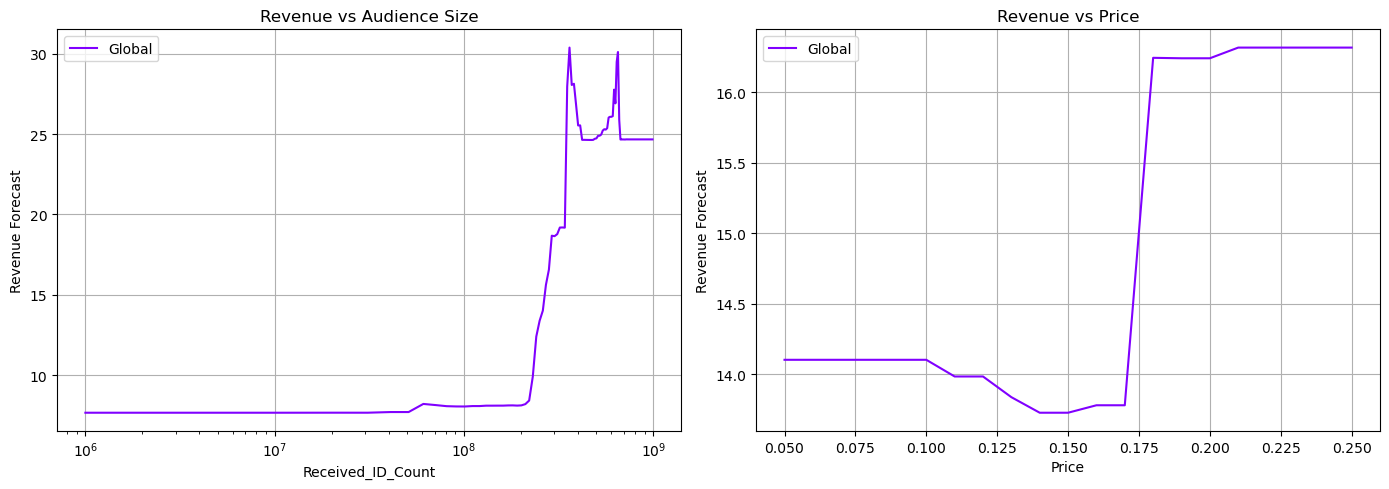

In [236]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Size sweep ---
size_grid = np.arange(1, 1000, 10) * 1_000_000
fc_size = sweep_forecast(X_rf, mod_d_rf, sc, 'Received_ID_Count', size_grid)
geos = fc_size['geo'].unique()
color = plt.cm.rainbow(np.linspace(0, 1, len(geos)))
for i, geo in enumerate(geos):
    sub = fc_size[fc_size['geo'] == geo]
    axes[0].plot(sub['Received_ID_Count_unscaled'], sub['revenue_forecast'], label=geo, color=color[i])
axes[0].set_xscale('log')
axes[0].set_xlabel('Received_ID_Count')
axes[0].set_ylabel('Revenue Forecast')
axes[0].set_title('Revenue vs Audience Size')
axes[0].legend()
axes[0].grid(True)

# --- Price sweep ---
price_grid = np.arange(0.05, 0.26, 0.01)
fc_price = sweep_forecast(X_rf, mod_d_rf, sc, 'price', price_grid)
geos_p = fc_price['geo'].unique()
color_p = plt.cm.rainbow(np.linspace(0, 1, len(geos_p)))
for i, geo in enumerate(geos_p):
    sub = fc_price[fc_price['geo'] == geo]
    axes[1].plot(sub['price_unscaled'], sub['revenue_forecast'], label=geo, color=color_p[i])
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Revenue Forecast')
axes[1].set_title('Revenue vs Price')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### per segment 

In [141]:
def plot_seg_forecasts(fc,
        x = 'Received_ID_Count_unscaled',
        y1 = 'relevance_forecast',
        y2 = 'revenue_forecast',
        x11 = None, #'Received_ID_Count_orig',
        y11 = None, #'current_size',
        title = '',
        legend_loc = None
    ):
    # 1. Get the current axes and create the second axes object
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx() # Instantiate a second axis that shares the same x-axis
    
    # 2. Plot the data on each axes object
    #y1 = y[0] if isinstance(y, list) else y
    ax1.plot(fc[x], fc[y1], color='blue', marker='.', label=y1, alpha=0.5)
    if x11 is not None and y11 is not None:
        ax1.plot(fc[x11], fc[y11], color='red', label=y11, alpha=0.7)
    ax2.plot(fc[x], fc[y2], color='green', marker='.', label=y2 + ' (right)')
    
    # 3. Set the labels
    ax1.set_xlabel(x)
    ax1.set_ylabel(y1, color='blue')
    ax2.set_ylabel(y2, color='green')
    
    # Optional: Improve layout and display legend
    if legend_loc:
        fig.tight_layout() # Ensures labels don't get clipped
        #ax1.legend(loc='lower left')
        #ax2.legend(loc='lower right')
        ax1.legend(loc=legend_loc)
        ax2.legend(loc=legend_loc)

    ax1.set_title(title)
    plt.show()


def get_seg_forecasts(X_rf, samples_sc, samples, seg_name):
    idx=0
    X_rf = X_rf[X_rf[seg_name] == 1]#.tail(1)
    samples_sc2 = pd.DataFrame(samples_sc[['Received_ID_Count']], copy=True)
    samples_sc2['fake_index'] = X_rf.index[idx]
    X_rf2 = X_rf[X_rf.columns[X_rf.columns != 'Received_ID_Count']]
    X_rf_forecast = samples_sc2.set_index('fake_index')[['Received_ID_Count']].join(
        X_rf2.head(idx + 1).tail(1)
    )
    yd_forecast = mod_d_rf.predict(X_rf_forecast[X_rf.columns])
    X_rf_forecast['revenue_forecast'] = yd_forecast
    X_rf_forecast['Received_ID_Count_unscaled'] = samples['Received_ID_Count'].values
    
    #temp2 = pd.DataFrame(X_rf_forecast[X_rf_forecast.columns[["geo" in c for c in X_rf_forecast.columns]]].sum())
    #temp2.columns = ['sum']
    #print(temp2[temp2["sum"] > 0].index)

    return X_rf_forecast
    

def get_forecasts(X_rf, samples_sc, samples, idx=0, seg_col='segment_last', seg_name=None):
    samples_sc2 = pd.DataFrame(samples_sc[['Received_ID_Count']], copy=True)
    samples_sc2['fake_index'] = X_rf.index[idx]
    
    X_rf2 = X_rf[X_rf.columns[X_rf.columns != 'Received_ID_Count']]
    X_rf_forecast = samples_sc2.set_index('fake_index')[['Received_ID_Count']].join(
        X_rf2.head(idx + 1).tail(1)
    )
    
    geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']
    
    yd_forecast = {}
    
    for geo in geos:
        X_rf_forecast[geos] = False
        X_rf_forecast[geo] = True
        yd_forecast[geo] = mod_d_rf.predict(X_rf_forecast[X_rf.columns])
    
    for geo in geos:
        g = geo.split('_')[1]
        X_rf_forecast['revenue_' + g] = yd_forecast[geo]
        
    X_rf_forecast['Received_ID_Count_unscaled'] = samples['Received_ID_Count'].values

    print (idx)
    temp = pd.DataFrame(X_rf_forecast[X_rf_forecast.columns[[seg_col in c for c in X_rf_forecast.columns]]].sum())
    temp.columns = ['sum']
    print(temp[temp["sum"] > 0].index)
    #temp2 = pd.DataFrame(X_rf_forecast[X_rf_forecast.columns[["geo" in c for c in X_rf_forecast.columns]]].sum())
    #temp2.columns = ['sum']
    #print(temp2[temp2["sum"] > 0].index)
    print(X_rf_forecast.shape)

    return X_rf_forecast